# Project overview

## Objective
This project aims to fit the US Treasury yield curve using NS and NSS models, and to compare their performance in terms of In-Sample Fitting and Out-Of-Sample Forecasting.
The frequency for data is Daily Treasury Par Yields.

## Data source and sample
- Daily Treasury Par Yields, not Zero-Coupon Yields
- CSV file downloaded from [Treasury website](https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?type=daily_treasury_yield_curve&field_tdr_date_value=2025)
- Sample: Year 2025
- Unit of Yields: originally in percentage(%), converted in decimal


## Modeling workflow
- One-Day data cleaning and Tenor-Mapping
- One-Day NS / NSS Fitting
- Rolling Fit to get Parameters Time Series
- In-Sample RMSE Comparison
- $t \to t+1$ OOS Testing
- Worst Dates Error Decomposition by Tenor

# Data Preparation

## Load and Inspect the Treasury yield Data
We first read the raw daily Treasury par-yield table and convert the Date column to datetime for sorting and rolling analysis.

In [396]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares

csv_path = "../data/daily-treasury-rates.csv"  
df = pd.read_csv(csv_path)

df["Date"] = pd.to_datetime(df["Date"])

# use the latest available date
row = df.sort_values("Date").iloc[-1]

df

,Date,1 Mo,1.5 Month,2 Mo,3 Mo,4 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
0,2025-12-31,3.74,3.75,3.67,3.67,3.63,3.59,3.48,3.47,3.55,3.73,3.94,4.18,4.79,4.84
1,2025-12-30,3.65,3.71,3.65,3.65,3.63,3.59,3.47,3.45,3.50,3.68,3.89,4.14,4.76,4.81
2,2025-12-29,3.69,3.70,3.70,3.68,3.66,3.59,3.48,3.45,3.51,3.67,3.88,4.12,4.75,4.80
3,2025-12-26,3.70,3.69,3.72,3.64,3.66,3.58,3.49,3.46,3.54,3.68,3.89,4.14,4.76,4.81
4,2025-12-24,3.72,3.73,3.74,3.69,3.67,3.59,3.50,3.47,3.56,3.70,3.91,4.15,4.75,4.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,2025-01-08,4.41,NaN,4.34,4.35,4.31,4.25,4.19,4.28,4.31,4.45,4.56,4.67,4.97,4.91
245,2025-01-07,4.42,NaN,4.35,4.35,4.31,4.24,4.19,4.30,4.33,4.46,4.57,4.67,4.97,4.91
246,2025-01-06,4.43,NaN,4.36,4.35,4.31,4.24,4.17,4.28,4.30,4.42,4.52,4.62,4.91,4.85
247,2025-01-03,4.44,NaN,4.35,4.34,4.31,4.25,4.18,4.28,4.32,4.41,4.51,4.60,4.88,4.82


## Tenor mapping (Columns to Maturity in years)
- We convert Tenors by mapping them in years, since the input for both NS and NSS models is continuous and in years.

In [397]:
# mapping：column -> time to maturity in years
TENOR_MAP = {
    "1 Mo":   1/12,
    "1.5 Mo": 1/12,
    "1.5 Month": 1.5/12,  
    "2 Mo":   2/12,
    "3 Mo":   3/12,
    "4 Mo":   4/12,
    "6 Mo":   6/12,
    "1 Yr":   1.0,
    "2 Yr":   2.0,
    "3 Yr":   3.0,
    "5 Yr":   5.0,
    "7 Yr":   7.0,
    "10 Yr":  10.0,
    "20 Yr":  20.0,
    "30 Yr":  30.0
}

## Cleaning and Unit conversion 
- Skip NA and Missing Values
- Sort Tenor to ensure the model fits the input in an ordered manner

In [398]:
taus = []
ys = []

for col, tau in TENOR_MAP.items():
    if col in row.index:
        val = row[col]
        # handling N/A
        try:
            v = float(val)
        except (TypeError, ValueError):
            continue
        if np.isfinite(v):
            taus.append(tau)
            ys.append(v / 100.0)  # convert % to decimal

taus = np.array(taus, dtype=float)
ys = np.array(ys, dtype=float)



## Build One-Day Curve Vectors
We first validate the model definition, fitting process, and visualisation logic using the One-Day example before extending it to Rolling

In [399]:
idx = np.argsort(taus)
taus, ys = taus[idx], ys[idx]

print("Selected date:", row["Date"].date())
print("Tenors (years):", taus)
print("Yields (decimals):", ys)

Selected date: 2025-12-31
Tenors (years): [ 0.08333333  0.125       0.16666667  0.25        0.33333333  0.5
  1.          2.          3.          5.          7.         10.
 20.         30.        ]
Yields (decimals): [0.0374 0.0375 0.0367 0.0367 0.0363 0.0359 0.0348 0.0347 0.0355 0.0373
 0.0394 0.0418 0.0479 0.0484]


# One-day curve fitting: NS vs. NSS



## Nelson-Siegel (NS) Model
$$\hat{y}^{\text{NS}}(\tau;\theta) = \beta_0+\beta_1 \frac{1-e^{-\lambda \tau}}{\lambda \tau} + \beta_2(\frac{1-e^{-\lambda \tau}}{\lambda \tau}-e^{-\lambda \tau})$$
$$\theta^{\text{NS}}=(\beta_{0},\beta_{1},\beta_{2},\lambda)$$
- $\beta_0$: long run level  
- $\beta_1$: short-end loading / slope-related
- $\beta_2$: curvature hump
- $\lambda$: decay speed
- $\tau$: maturity in years
- $\tau_i$: i-th tenor
- $y_t(\tau_i)$: observed market yieldon date $t$ at maturity $\tau_i$
- $n_t$: number of available points at time $t$
- Optimization objective function: Least Squared function
- Constraint: $\lambda>0$


In [400]:
# Nelson–Siegel model 
def ns_yield(tau, beta0, beta1, beta2, lam):

    # Maturities start from 1M, so tau > 0 in our dataset.
    tau = np.asarray(tau)
    x = lam * tau

    # define basis functions
    factor1 = (1.0 - np.exp(-x)) / x
    factor2 = factor1 - np.exp(-x)

    return beta0 + beta1 * factor1 + beta2 * factor2


def ns_residuals(params, tau, y_obs):
    
    beta0, beta1, beta2, lam = params
    y_hat = ns_yield(tau, beta0, beta1, beta2, lam)

    return y_obs - y_hat


# initial values
y_short = ys[0]
y_long = ys[-1]
beta0_0 = y_long                  
beta1_0 = y_short - y_long        
beta2_0 = 0.0
lam_0 = 1.0

x0 = np.array([beta0_0, beta1_0, beta2_0, lam_0])

The model parameters $\beta_i$ and $t$ can be estimated using a "Least squares approach", the optimal parameters are set such that the sum of squared errors is minimized.
$$\text{RMSE}^{NS}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(\epsilon_i^{\text{NS}})^2}$$
where residuals are define $\epsilon_i^{\text{NS}}=y(\tau_i)-\hat{y}^{\text{NS}}(\tau_i)$

In [401]:
# set constraint：lam > 0
lb = np.array([-1.0, -1.0, -1.0, 1e-6])
ub = np.array([ 1.0,  1.0,  1.0, 20.0])

res_ns = least_squares(
    ns_residuals, x0, bounds=(lb, ub),
    args=(taus, ys),
    loss="linear"   # could use "huber" to increase robustness
)

beta0, beta1, beta2, lam = res_ns.x
rmse_ns = np.sqrt(np.mean(res_ns.fun**2))

## NSS: Nelson-Siegel-Svensson (NSS) Model
$$\hat{y}^{\text{NSS}}(\tau;\theta) = \beta_0 + \beta_1\frac{1-e^{-\lambda \tau}}{\lambda \tau} + \beta_2(\frac{1-e^{-\lambda \tau}}{\lambda \tau}-e^{-\lambda \tau})+\beta_3(\frac{1-e^{-\mu \tau}}{\mu \tau}-e^{-\mu \tau})$$
$$\theta^{\text{NSS}}=(\beta_{0},\beta_{1},\beta_{2},\beta_{3},\lambda,\mu)$$
- second curvature component $\beta_3$ increases the fitting flexibility for complex shape of curve.

In [402]:
# Nelson–Siegel-Svensson model 
def nss_yield(tau, beta0, beta1, beta2, beta3, lam, mu):

    tau = np.asarray(tau)
    x1 = lam * tau
    x2 = mu  * tau
    
    # again basis functions
    factor1 = (1.0 - np.exp(-x1)) / x1
    factor2 = factor1 - np.exp(-x1)
    factor3 = (1.0 - np.exp(-x2)) / x2 - np.exp(-x2)

    return beta0 + beta1 * factor1 + beta2 * factor2 + beta3 * factor3


def nss_residuals(params, tau, y_obs):

    beta0, beta1, beta2, beta3, lam, mu = params
    y_hat = nss_yield(tau, beta0, beta1, beta2, beta3, lam, mu)

    return y_obs - y_hat


# use NS result as initial value
x0_nss = np.array([beta0, beta1, beta2, 0.0, lam, 0.3])

lb_nss = np.array([-1.0, -1.0, -1.0, -1.0, 1e-6, 1e-6])
ub_nss = np.array([ 1.0,  1.0,  1.0,  1.0, 15.0, 15.0])


res_nss = least_squares(
    nss_residuals, x0_nss, bounds=(lb_nss, ub_nss),
    args=(taus, ys),
    loss="linear"
)

rmse_nss = np.sqrt(np.mean(res_nss.fun**2))
print("\nNSS fit:")
print("beta0,beta1,beta2,beta3,lambda,mu =", res_nss.x)
print("RMSE =", rmse_nss)


NSS fit:
beta0,beta1,beta2,beta3,lambda,mu = [ 0.05267427 -0.01467834 -0.01247963 -0.03942811  1.43597031  0.42297398]
RMSE = 0.0003092477929192986


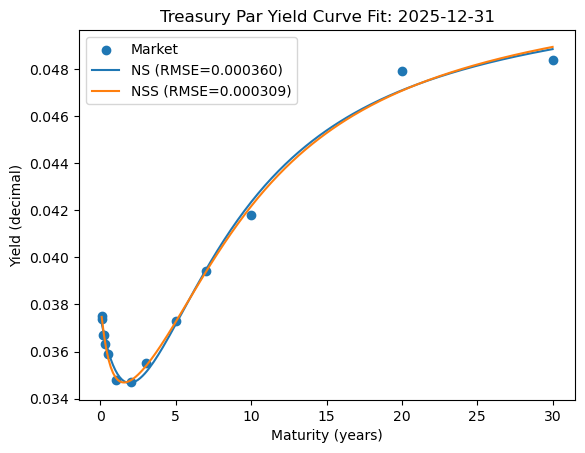

In [403]:
# plot
t_grid = np.linspace(taus.min(), taus.max(), 200)

y_fit_ns = ns_yield(t_grid, *res_ns.x)
y_fit_nss = nss_yield(t_grid, *res_nss.x)

plt.figure()
plt.scatter(taus, ys, label="Market")
plt.plot(t_grid, y_fit_ns, label=f"NS (RMSE={rmse_ns:.6f})")
plt.plot(t_grid, y_fit_nss, label=f"NSS (RMSE={rmse_nss:.6f})")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (decimal)")
plt.title(f"Treasury Par Yield Curve Fit: {row['Date'].date()}")
plt.legend()
plt.show()

On the selected date (2025-12-31), both NS and NSS reproduce the overall upward-sloping Treasury par-yield curve, while NSS achieves a slightly lower In-Sample RMSE.

The NSS extension adds an extra curvature term, which improves local shape flexibility. This leads to a better fit in several tenors, but residuals at the long end (especially 20Y and 30Y) remain non-negligible.

This is a one-day cross-sectional fit and should be interpreted as an implementation check rather than evidence of superior forecasting performance.

## Interpretation of the One-Day Fit 
Purpose: Assess whether NS and NSS capture the cross-sectional curve shape on a representative date and identify where residuals concentrate by Tenor.

Observations
- Both NS and NSS catch the overall shape
- NSS achieves a lower In-Sample RMSE than NS on this date
- Residuals are primarily concentrated in Tenors at long (especially 20Y/30Y ), indicating that tail behaviour remains difficult even under NSS




Use bp for residuals as it's more intuitive.

In [404]:
def tenor_label(t):

    if t < 1:
        m = t * 12
        if abs(m - 1.5) < 1e-9:
            return "1.5M"
        if abs(m - round(m)) < 1e-9:
            return f"{int(round(m))}M"
        return f"{m:.1f}M"
    else:
        if abs(t - round(t)) < 1e-9:
            return f"{int(round(t))}Y"
        return f"{t:.1f}Y"

# compute the fitted values
yhat_ns  = ns_yield(taus, *res_ns.x)
yhat_nss = nss_yield(taus, *res_nss.x)

df_curve = pd.DataFrame({
    "tenor_years": taus,
    "tenor": [tenor_label(t) for t in taus],
    "yield_market": ys,
    "yield_NS": yhat_ns,
    "yield_NSS": yhat_nss,
})

# resiudals in bp
df_curve["err_NS"]  = df_curve["yield_market"] - df_curve["yield_NS"]
df_curve["err_NSS"] = df_curve["yield_market"] - df_curve["yield_NSS"]

df_curve["err_NS_bp"]  = df_curve["err_NS"]  * 1e4
df_curve["err_NSS_bp"] = df_curve["err_NSS"] * 1e4

# yields in percentages
df_display = df_curve.copy()
for c in ["yield_market", "yield_NS", "yield_NSS"]:
    df_display[c] = (100 * df_display[c]).map(lambda x: f"{x:.3f}%")
for c in ["err_NS_bp", "err_NSS_bp"]:
    df_display[c] = df_display[c].map(lambda x: f"{x:+.2f} bp")


df_display = df_display.sort_values("tenor_years")[[
    "tenor", "tenor_years", "yield_market", "yield_NS", "yield_NSS", "err_NS_bp", "err_NSS_bp"
]]

df_display

,tenor,tenor_years,yield_market,yield_NS,yield_NSS,err_NS_bp,err_NSS_bp
0,1M,0.083333,3.740%,3.720%,3.747%,+1.98 bp,-0.72 bp
1,1.5M,0.125000,3.750%,3.707%,3.724%,+4.33 bp,+2.63 bp
2,2M,0.166667,3.670%,3.694%,3.702%,-2.36 bp,-3.19 bp
3,3M,0.250000,3.670%,3.669%,3.663%,+0.11 bp,+0.71 bp
4,4M,0.333333,3.630%,3.646%,3.629%,-1.60 bp,+0.07 bp
5,6M,0.500000,3.590%,3.605%,3.576%,-1.53 bp,+1.41 bp
6,1Y,1.000000,3.480%,3.519%,3.491%,-3.95 bp,-1.08 bp
7,2Y,2.000000,3.470%,3.467%,3.477%,+0.31 bp,-0.74 bp
8,3Y,3.000000,3.550%,3.511%,3.537%,+3.92 bp,+1.29 bp
9,5Y,5.000000,3.730%,3.716%,3.727%,+1.38 bp,+0.33 bp


# Rolling fit 
## Rolling NS Fit
For each trading day $t$, we try to fit with NS
$$\theta_t = (\beta_0(t), \beta_1(t), \beta_2(t), \lambda(t)) $$
We set minimum  ```min_points``` to make sure we have enough points for fitting.

In [405]:
df = pd.read_csv(csv_path)

df["Date"] = pd.to_datetime(df["Date"])

# we need to melt the dataframe
row = df.sort_values("Date").reset_index(drop=True)

# with the previous TENOR_MAP
tenor_cols = [c for c in TENOR_MAP.keys() if c in df.columns]

long = df[["Date"] + tenor_cols].melt(
    id_vars="Date", var_name="tenor_col", value_name="yield_pct"
)

# convert to numeric and drop NA
long["yield_pct"] = pd.to_numeric(long["yield_pct"], errors="coerce")
long = long.dropna(subset=["yield_pct"])

long["tenor_years"] = long["tenor_col"].map(TENOR_MAP)
long["yield"] = long["yield_pct"] / 100.0  # % -> decimal

# set minimum (for example >=9)
min_points = 9
counts = long.groupby("Date")["tenor_years"].count()
valid_dates = counts[counts >= min_points].index
long = long[long["Date"].isin(valid_dates)]

In [406]:
def ns_yield(tau, beta0, beta1, beta2, lam):
    
    tau = np.asarray(tau, dtype=float)
    x = lam * tau
    factor1 = (1.0 - np.exp(-x)) / x
    factor2 = factor1 - np.exp(-x)

    return beta0 + beta1 * factor1 + beta2 * factor2

def ns_residuals(params, tau, y_obs):

    beta0, beta1, beta2, lam = params

    return y_obs - ns_yield(tau, beta0, beta1, beta2, lam)

def fit_ns_one_day(day_df, x0=None):

    # day_df: columns [tenor_years, yield]
    tau = day_df["tenor_years"].to_numpy(float)
    y = day_df["yield"].to_numpy(float)

    idx = np.argsort(tau)
    tau, y = tau[idx], y[idx]

    if x0 is None:
        y_short, y_long = y[0], y[-1]
        beta0_0 = y_long
        beta1_0 = y_short - y_long
        beta2_0 = 0.0
        lam_0 = 1.0
        x0 = np.array([beta0_0, beta1_0, beta2_0, lam_0], dtype=float)

    # bounds：lam > 0
    lb = np.array([-1.0, -1.0, -1.0, 1e-6])
    ub = np.array([ 1.0,  1.0,  1.0, 15.0])

    res = least_squares(
        ns_residuals, x0, bounds=(lb, ub),
        args=(tau, y), loss="linear"
    )
    rmse = np.sqrt(np.mean(res.fun**2))
    
    return res.x, rmse, len(y)

## NS Parameters Time Series and Ecomonic Interpretation

In [407]:
# select the latest 250 trading days
dates = sorted(long["Date"].unique())
N = 250
dates = dates[-N:] if len(dates) > N else dates

rows = []
x_prev = None

for d in dates:
    day_df = long[long["Date"] == d][["tenor_years", "yield"]]
    params, rmse, npts = fit_ns_one_day(day_df, x0=x_prev)  # warm start
    x_prev = params  # use it as initial value for the next day

    rows.append({
        "Date": d,
        "beta0": params[0],
        "beta1": params[1],
        "beta2": params[2],
        "lambda": params[3],
        "rmse": rmse,
        "n_points": npts
    })

df_params = pd.DataFrame(rows).sort_values("Date").reset_index(drop=True)
df_params["short_level"] = df_params["beta0"] + df_params["beta1"]
df_params["long_level"]  = df_params["beta0"]

df_params.head(), df_params.tail()

(        Date     beta0     beta1     beta2    lambda      rmse  n_points  \
 0 2025-01-02  0.049292 -0.005046 -0.015642  0.664981  0.000437        13   
 1 2025-01-03  0.049507 -0.005432 -0.014788  0.671233  0.000427        13   
 2 2025-01-06  0.049897 -0.005772 -0.015817  0.671158  0.000425        13   
 3 2025-01-07  0.050585 -0.006587 -0.015677  0.654325  0.000415        13   
 4 2025-01-08  0.050702 -0.006740 -0.016006  0.631227  0.000375        13   
 
    short_level  long_level  
 0     0.044246    0.049292  
 1     0.044075    0.049507  
 2     0.044125    0.049897  
 3     0.043998    0.050585  
 4     0.043962    0.050702  ,
           Date     beta0     beta1     beta2    lambda      rmse  n_points  \
 244 2025-12-24  0.051923 -0.014307 -0.030532  0.424902  0.000358        14   
 245 2025-12-26  0.052400 -0.015091 -0.030777  0.405016  0.000352        14   
 246 2025-12-29  0.052320 -0.014934 -0.031406  0.407170  0.000337        14   
 247 2025-12-30  0.052408 -0.015294 -0.

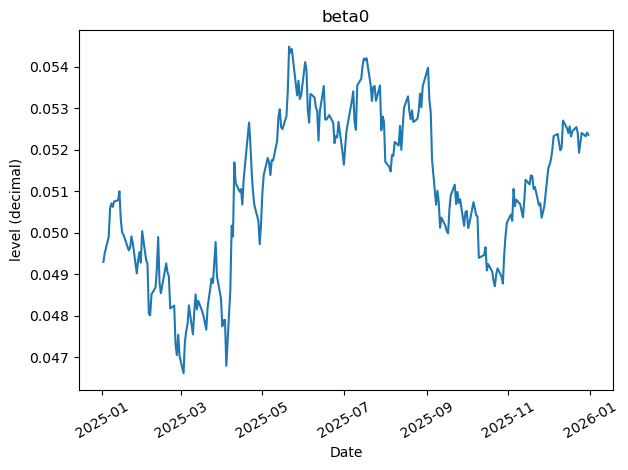

In [408]:
def plot_series(df, col, ylabel):
    
    plt.figure()
    plt.plot(df["Date"], df[col])
    plt.title(col)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

plot_series(df_params, "beta0", "level (decimal)")

$\beta_{0,t}$ generally reflects the long end-level, with a higher mid-year point followed by a rebound after the autumn decline.

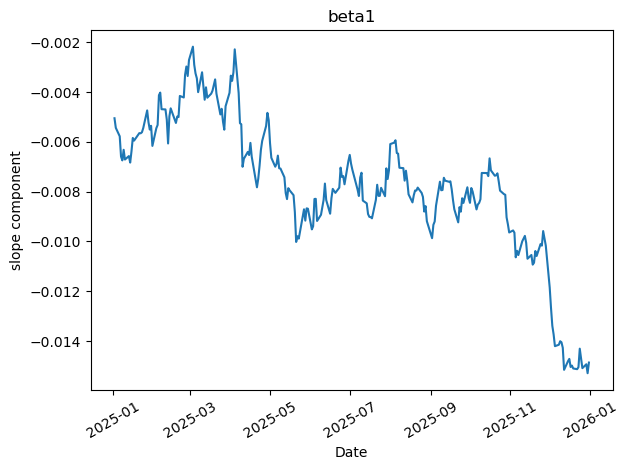

In [409]:
plot_series(df_params, "beta1", "slope component")

As $\beta_{1,t}$ rises, the steepness of the curve increases, consistent with subsequent results (high correlation).

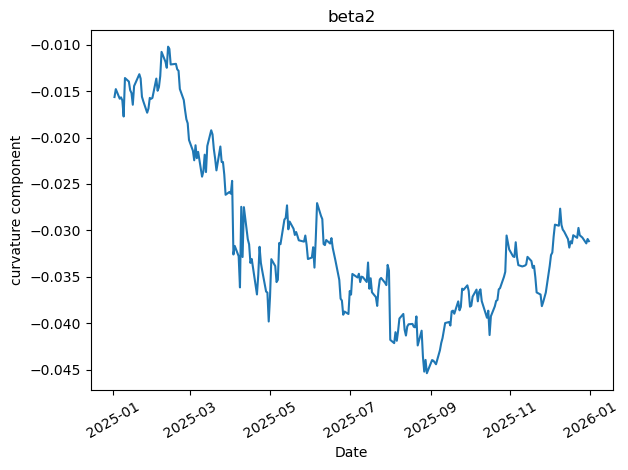

In [410]:
plot_series(df_params, "beta2", "curvature component")

The level of curvature in the middle section of the curve has undergone a marked change within the year.

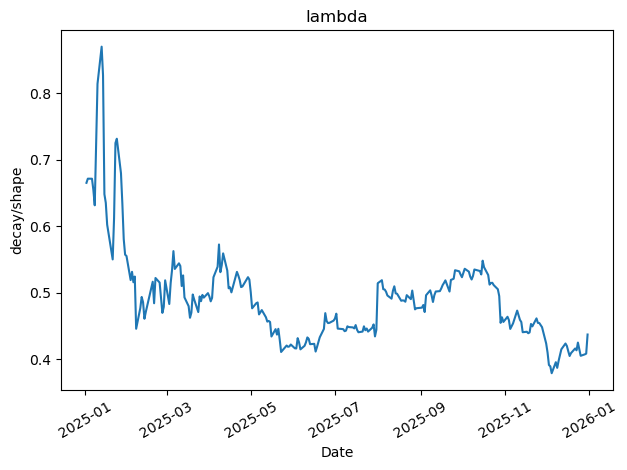

In [411]:
plot_series(df_params, "lambda", "decay/shape")

$\lambda_t$ exhibits considerable volatility in the early stages, with relative stability in the later period.

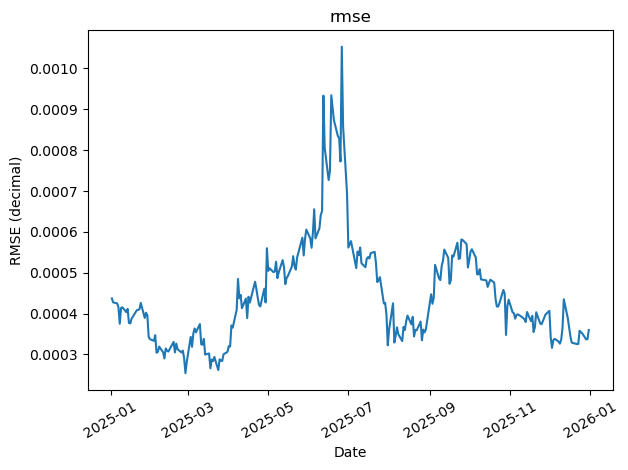

In [412]:
plot_series(df_params, "rmse", "RMSE (decimal)")

### Economic Interpretation Checks
To validate the economic interpretation of NS parameters, I compare parameter-based proxies with observed market yields/spreads:

-  $\beta_{0,t}$ as a proxy for the long-end level (compared with 30Y-Yield),
-  $\beta_{0,t} + \beta_{1,t}$ as a proxy for the short-end level (compared with 1M-Yield),
-  $-\beta_{1,t}$ as a proxy for the slope (compared with $30Y - 1M$).

The correlations are high for the intended mappings (especially short-level and slope proxy), which supports the standard NS parameter interpretation in this sample.
<br>These checks are intended as empirical consistency tests for standard NS parameter interpretation, not as structural identification. The parameters are jointly estimated from the full cross-section, so each parameter can still be affected by movements across multiple maturities.

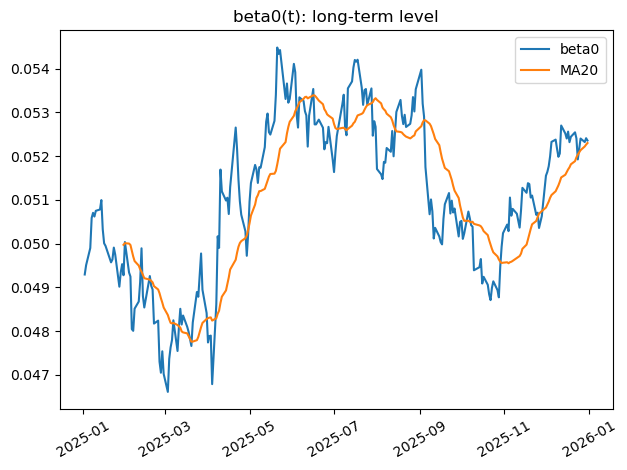

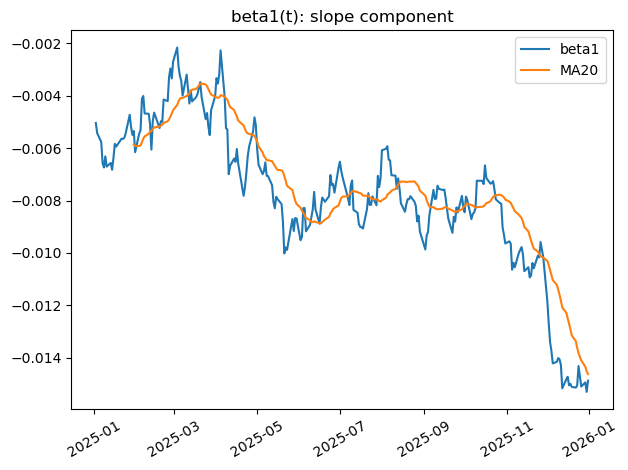

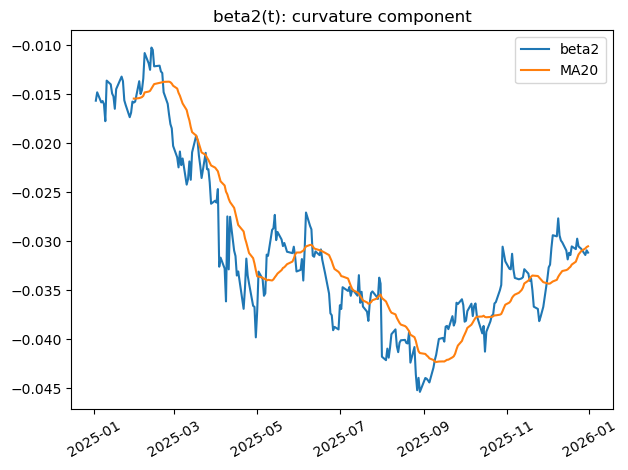

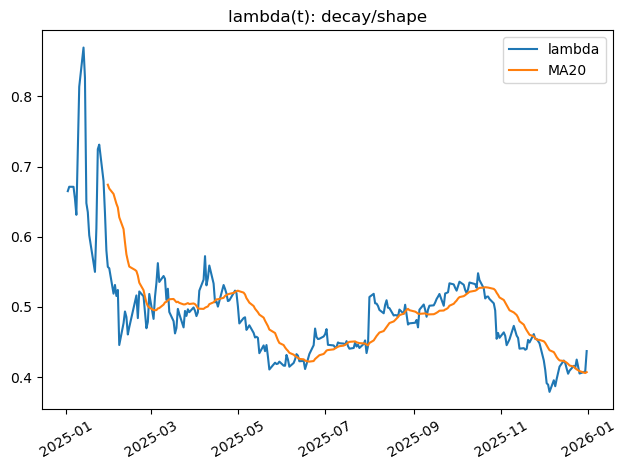

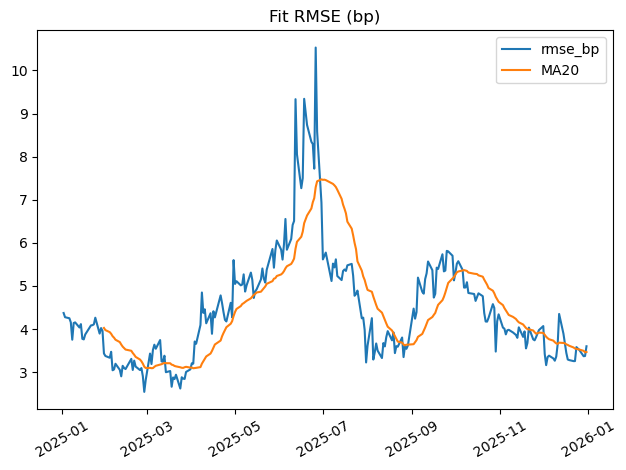

In [413]:
def plot(df, col, title=None):
    plt.figure()
    plt.plot(df["Date"], df[col], label=col)
    if col + "_ma20" in df.columns:
        plt.plot(df["Date"], df[col + "_ma20"], label="MA20")
    plt.title(title or col)
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.show()

df_params["rmse_bp"] = df_params["rmse"]*1e4
for c in ["beta0","beta1","beta2","lambda","rmse_bp"]:
    df_params[c+"_ma20"] = df_params[c].rolling(20).mean()

plot(df_params, "beta0", "beta0(t): long-term level")
plot(df_params, "beta1", "beta1(t): slope component")
plot(df_params, "beta2", "beta2(t): curvature component")
plot(df_params, "lambda", "lambda(t): decay/shape")
plot(df_params, "rmse_bp", "Fit RMSE (bp)")

In [414]:
# validate: compare short-/long-term level with real interest rate and their correlation
# using 1M and 30Y yields
mkt_1m  = long[long["tenor_years"]==1/12].set_index("Date")["yield"].rename("y_1m")
mkt_30y = long[long["tenor_years"]==30].set_index("Date")["yield"].rename("y_30y")

tmp = df_params.set_index("Date").join([mkt_1m, mkt_30y], how="inner")
tmp["short_level"] = tmp["beta0"] + tmp["beta1"]
tmp["long_level"] = tmp["beta0"]

# print correlation matrix
print(tmp[["short_level","y_1m","long_level","y_30y"]].corr())

             short_level      y_1m  long_level     y_30y
short_level     1.000000  0.946466    0.031160  0.242234
y_1m            0.946466  1.000000   -0.115367  0.158617
long_level      0.031160 -0.115367    1.000000  0.883804
y_30y           0.242234  0.158617    0.883804  1.000000


We notice that we have high $\text{corr}(\beta_0(t), y_t(30\text{Y}))$ value

### Diagnosing Difficult NS Fitting Dates
The worst In-Sample NS fitting dates cluster around mid-to-late June 2025. On these dates, the largest errors appear simultaneously at the very short end (1M–6M) and the long end (20Y/30Y), while the belly is fitted relatively well.

This pattern suggests that the single-curvature NS structure is too restrictive when the curve exhibits stronger local shape distortions at both ends.

In [415]:
top = df_params.nlargest(10, "rmse")["Date"]
top.tolist()

[Timestamp('2025-06-26 00:00:00'),
 Timestamp('2025-06-18 00:00:00'),
 Timestamp('2025-06-12 00:00:00'),
 Timestamp('2025-06-20 00:00:00'),
 Timestamp('2025-06-27 00:00:00'),
 Timestamp('2025-06-23 00:00:00'),
 Timestamp('2025-06-24 00:00:00'),
 Timestamp('2025-06-13 00:00:00'),
 Timestamp('2025-06-25 00:00:00'),
 Timestamp('2025-06-17 00:00:00')]

           slope_mkt  slope_ns
slope_mkt   1.000000  0.964396
slope_ns    0.964396  1.000000


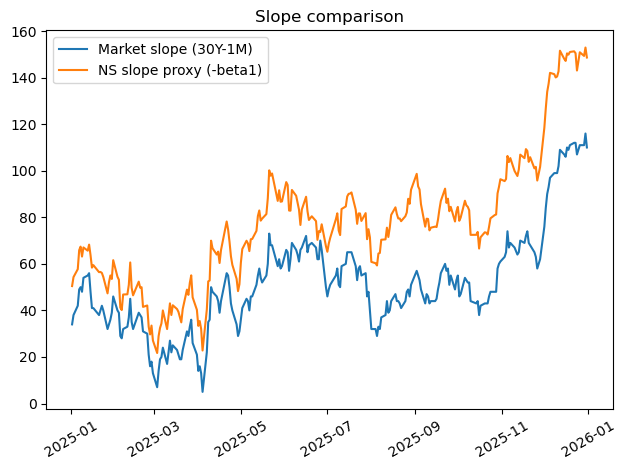

In [416]:
tmp = tmp.copy()
tmp["slope_mkt"] = (tmp["y_30y"] - tmp["y_1m"]) * 1e4      # in bp
tmp["slope_ns"]  = (-tmp["beta1"]) * 1e4                   # in bp

print(tmp[["slope_mkt","slope_ns"]].corr())

plt.figure()
plt.plot(tmp.index, tmp["slope_mkt"], label="Market slope (30Y-1M)")
plt.plot(tmp.index, tmp["slope_ns"], label="NS slope proxy (-beta1)")
plt.title("Slope comparison")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

      tenor_years   yield  yield_ns     err_bp
128      0.083333  0.0411  0.044340 -32.395833
377      0.125000  0.0447  0.044060   6.400084
626      0.166667  0.0449  0.043788  11.116885
875      0.250000  0.0439  0.043268   6.320031
1124     0.333333  0.0436  0.042777   8.227050
1373     0.500000  0.0426  0.041880   7.203790
1622     1.000000  0.0396  0.039773  -1.733725
1871     2.000000  0.0370  0.037528  -5.281753
2120     3.000000  0.0368  0.036932  -1.318511
2369     5.000000  0.0379  0.037981  -0.809364
2618     7.000000  0.0400  0.039915   0.851688
2867    10.000000  0.0426  0.042590   0.104208
3116    20.000000  0.0481  0.047184   9.158062
3365    30.000000  0.0481  0.048884  -7.842618


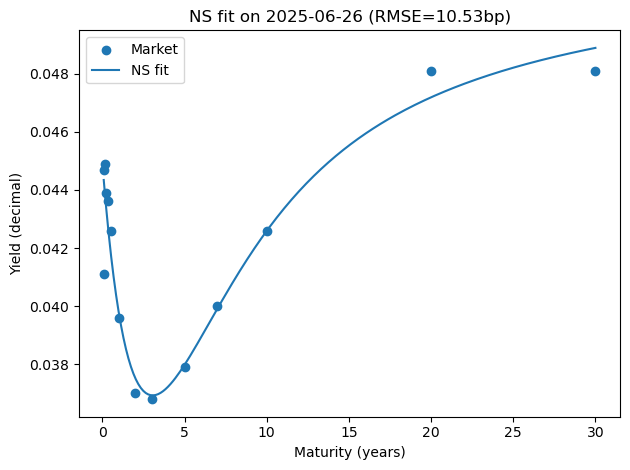

      tenor_years   yield  yield_ns     err_bp
133      0.083333  0.0420  0.044430 -24.303838
382      0.125000  0.0436  0.044235  -6.349362
631      0.166667  0.0458  0.044045  17.551905
880      0.250000  0.0442  0.043680   5.199140
1129     0.333333  0.0441  0.043335   7.646317
1378     0.500000  0.0433  0.042703   5.972729
1627     1.000000  0.0410  0.041206  -2.063561
1876     2.000000  0.0394  0.039586  -1.862056
2125     3.000000  0.0389  0.039153  -2.527895
2374     5.000000  0.0398  0.039989  -1.888627
2623     7.000000  0.0417  0.041568   1.320975
2872    10.000000  0.0438  0.043842  -0.420948
3121    20.000000  0.0489  0.047975   9.248486
3370    30.000000  0.0488  0.049552  -7.523242


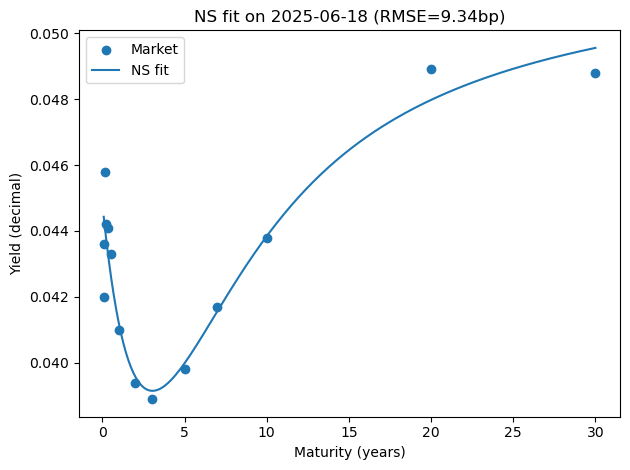

      tenor_years   yield  yield_ns     err_bp
137      0.083333  0.0418  0.044127 -23.267767
386      0.125000  0.0430  0.043927  -9.267841
635      0.166667  0.0449  0.043732  11.676225
884      0.250000  0.0446  0.043360  12.401446
1133     0.333333  0.0440  0.043008   9.917012
1382     0.500000  0.0429  0.042365   5.353892
1631     1.000000  0.0406  0.040852  -2.522302
1880     2.000000  0.0390  0.039247  -2.474868
2129     3.000000  0.0385  0.038855  -3.546250
2378     5.000000  0.0397  0.039766  -0.657632
2627     7.000000  0.0415  0.041379   1.213343
2876    10.000000  0.0436  0.043645  -0.450317
3125    20.000000  0.0486  0.047662   9.380249
3374    30.000000  0.0484  0.049176  -7.755189


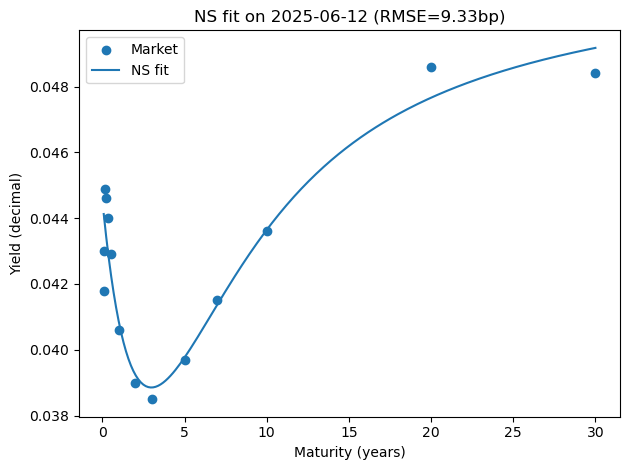

      tenor_years   yield  yield_ns     err_bp
132      0.083333  0.0420  0.044346 -23.458587
381      0.125000  0.0438  0.044134  -3.342499
630      0.166667  0.0455  0.043929  15.714191
879      0.250000  0.0439  0.043535   3.654371
1128     0.333333  0.0440  0.043163   8.371696
1377     0.500000  0.0429  0.042483   4.174874
1626     1.000000  0.0407  0.040886  -1.861658
1875     2.000000  0.0390  0.039199  -1.991359
2124     3.000000  0.0386  0.038794  -1.938422
2373     5.000000  0.0396  0.039769  -1.693366
2622     7.000000  0.0416  0.041476   1.244403
2871    10.000000  0.0438  0.043862  -0.618490
3120    20.000000  0.0490  0.048072   9.284867
3369    30.000000  0.0489  0.049654  -7.540022


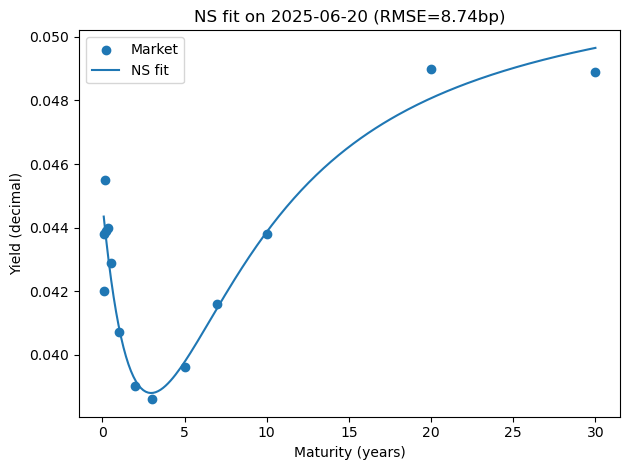

      tenor_years   yield  yield_ns     err_bp
127      0.083333  0.0419  0.044395 -24.948304
376      0.125000  0.0443  0.044121   1.789149
625      0.166667  0.0449  0.043855  10.448504
874      0.250000  0.0439  0.043346   5.539748
1123     0.333333  0.0436  0.042866   7.338738
1372     0.500000  0.0426  0.041989   6.110520
1621     1.000000  0.0397  0.039936  -2.361693
1870     2.000000  0.0373  0.037769  -4.690850
2119     3.000000  0.0372  0.037224  -0.235650
2368     5.000000  0.0383  0.038327  -0.266253
2617     7.000000  0.0403  0.040282   0.175804
2866    10.000000  0.0429  0.042967  -0.673785
3115    20.000000  0.0485  0.047562   9.378675
3364    30.000000  0.0485  0.049260  -7.604601


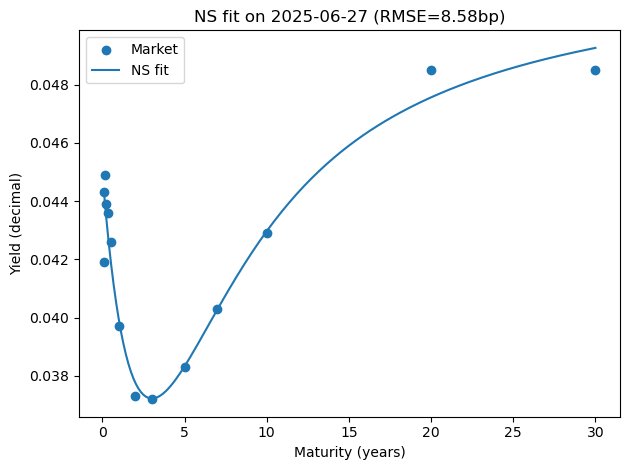

In [417]:
top_dates = df_params.nlargest(5, "rmse")["Date"].tolist()
top_dates

def curve_table_and_plot(date):
    
    day = long[long["Date"]==date][["tenor_years","yield"]].copy()
    day = day.sort_values("tenor_years")

    p = df_params.set_index("Date").loc[date, ["beta0","beta1","beta2","lambda"]].to_numpy(float)
    yhat = ns_yield(day["tenor_years"].to_numpy(), *p)

    out = day.copy()
    out["yield_ns"] = yhat
    out["err_bp"] = (out["yield"] - out["yield_ns"]) * 1e4
    print(out)

    # plot
    t_grid = np.linspace(out["tenor_years"].min(), out["tenor_years"].max(), 200)
    y_grid = ns_yield(t_grid, *p)

    plt.figure()
    plt.scatter(out["tenor_years"], out["yield"], label="Market")
    plt.plot(t_grid, y_grid, label="NS fit")
    plt.title(f"NS fit on {pd.to_datetime(date).date()} (RMSE={df_params.set_index('Date').loc[date,'rmse']*1e4:.2f}bp)")
    plt.xlabel("Maturity (years)")
    plt.ylabel("Yield (decimal)")
    plt.legend()
    plt.tight_layout()
    plt.show()

for d in top_dates:
    curve_table_and_plot(d)

## Rolling NSS Fit
Because NSS has more parameters than NS, rolling estimation is more sensitive to initialization. We therefore use the following strategy:

1. reuse the previous day’s NSS parameters when available;
2. otherwise initialize NSS from the same-day NS fit by setting $\beta_3=0$ and a default $\mu$.

This improves robustness of the rolling optimization and reduces failed fits.

In [418]:
def fit_nss_one_day(day_df, x0=None):
    tau = day_df["tenor_years"].to_numpy(float)
    y   = day_df["yield"].to_numpy(float)

    idx = np.argsort(tau)
    tau, y = tau[idx], y[idx]

    if x0 is None:
        y_short, y_long = y[0], y[-1]
        beta0_0 = y_long
        beta1_0 = y_short - y_long
        beta2_0 = 0.0
        beta3_0 = 0.0
        lam_0 = 1.0
        mu_0  = 0.3
        x0 = np.array([beta0_0, beta1_0, beta2_0, beta3_0, lam_0, mu_0], dtype=float)

    lb = np.array([-1.0, -1.0, -1.0, -1.0, 1e-4, 1e-4])
    ub = np.array([ 1.0,  1.0,  1.0,  1.0,  10.0,  10.0])

    res = least_squares(
        nss_residuals, x0, bounds=(lb, ub),
        args=(tau, y), loss="linear"
    )
    rmse = np.sqrt(np.mean(res.fun**2))
    return res.x, rmse, len(y)

Running both NS and NSS and compare the result

In [419]:
dates = sorted(long["Date"].unique())
N = 250
dates = dates[-N:] if len(dates) > N else dates

rows_ns = []
rows_nss = []

x_prev_ns = None
x_prev_nss = None

for d in dates:
    day_df = long[long["Date"] == d][["tenor_years", "yield"]]
    
    # ----- NS -----
    try:
        p_ns, rmse_ns, npts = fit_ns_one_day(day_df, x0=x_prev_ns)
        x_prev_ns = p_ns
        ok_ns = True
    except Exception:
        p_ns = [np.nan]*4
        rmse_ns = np.nan
        npts = len(day_df)
        ok_ns = False

    rows_ns.append({
        "Date": d, "beta0": p_ns[0], "beta1": p_ns[1], "beta2": p_ns[2], "lambda": p_ns[3],
        "rmse": rmse_ns, "n_points": npts, "ok": ok_ns
    })

    # ----- NSS -----
    if x_prev_nss is None and ok_ns:
        # use NS as starting point, beta3=0, mu=0.3
        x0_nss = np.array([p_ns[0], p_ns[1], p_ns[2], 0.0, max(p_ns[3], 0.3), 0.3], dtype=float)
    else:
        x0_nss = x_prev_nss

    try:
        p_nss, rmse_nss, npts2 = fit_nss_one_day(day_df, x0=x0_nss)
        x_prev_nss = p_nss
        ok_nss = True
    except Exception:
        if ok_ns:
            x0_nss_fb = np.array([p_ns[0], p_ns[1], p_ns[2], 0.0, max(p_ns[3], 0.3), 0.3], dtype=float)
            try:
                p_nss, rmse_nss, npts2 = fit_nss_one_day(day_df, x0=x0_nss_fb)
                x_prev_nss = p_nss
                ok_nss = True
            except Exception:
                p_nss = [np.nan]*6
                rmse_nss = np.nan
                npts2 = len(day_df)
                ok_nss = False
        else:
            p_nss = [np.nan]*6
            rmse_nss = np.nan
            npts2 = len(day_df)
            ok_nss = False

    rows_nss.append({
        "Date": d,
        "beta0": p_nss[0], "beta1": p_nss[1], "beta2": p_nss[2], "beta3": p_nss[3],
        "lambda": p_nss[4], "mu": p_nss[5],
        "rmse": rmse_nss, "n_points": npts2, "ok": ok_nss
    })


## In-Sample RMSE Comparison: NS vs NSS

In [420]:
df_ns  = pd.DataFrame(rows_ns).sort_values("Date").reset_index(drop=True)
df_nss = pd.DataFrame(rows_nss).sort_values("Date").reset_index(drop=True)

# merge for comparison
df_compare = df_ns[["Date","rmse","ok"]].rename(columns={"rmse":"rmse_ns","ok":"ok_ns"}) \
    .merge(df_nss[["Date","rmse","ok"]].rename(columns={"rmse":"rmse_nss","ok":"ok_nss"}), on="Date", how="inner")

df_compare["rmse_ns_bp"]  = df_compare["rmse_ns"]  * 1e4
df_compare["rmse_nss_bp"] = df_compare["rmse_nss"] * 1e4
df_compare["rmse_gain_bp"] = df_compare["rmse_ns_bp"] - df_compare["rmse_nss_bp"]  # >0 means NSS performs better

df_compare.head()

,Date,rmse_ns,ok_ns,rmse_nss,ok_nss,rmse_ns_bp,rmse_nss_bp,rmse_gain_bp
0,2025-01-02,0.000437,True,0.000313,True,4.372254,3.131063,1.241191
1,2025-01-03,0.000427,True,0.000294,True,4.274710,2.935041,1.339669
2,2025-01-06,0.000425,True,0.000306,True,4.250449,3.057301,1.193148
3,2025-01-07,0.000415,True,0.000307,True,4.154833,3.074687,1.080147
4,2025-01-08,0.000375,True,0.000304,True,3.752730,3.039674,0.713056


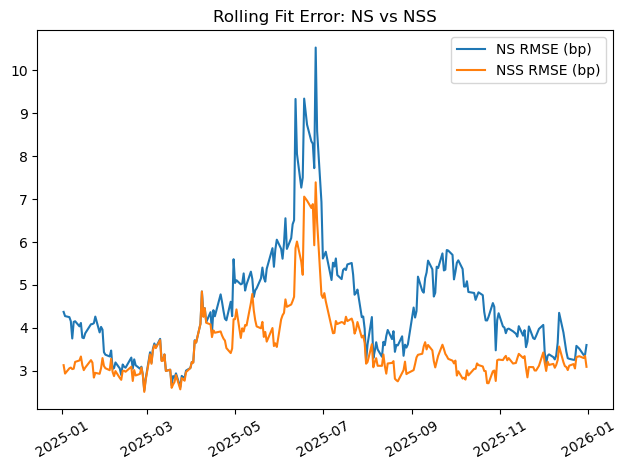

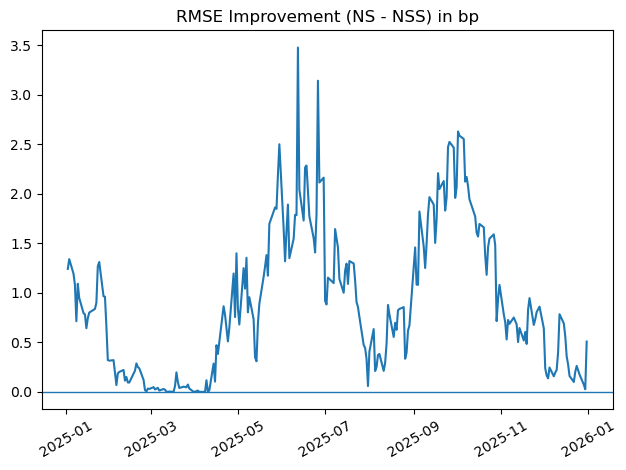

Average RMSE (bp):
NS : 4.430138374590124
NSS: 3.53539857584159
Average improvement (bp): 0.8947397987485336
Share of days where NSS improves: 0.9959839357429718


In [421]:
plt.figure()
plt.plot(df_compare["Date"], df_compare["rmse_ns_bp"], label="NS RMSE (bp)")
plt.plot(df_compare["Date"], df_compare["rmse_nss_bp"], label="NSS RMSE (bp)")
plt.title("Rolling Fit Error: NS vs NSS")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df_compare["Date"], df_compare["rmse_gain_bp"])
plt.axhline(0, linewidth=1)
plt.title("RMSE Improvement (NS - NSS) in bp")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Average RMSE (bp):")
print("NS :", df_compare["rmse_ns_bp"].mean())
print("NSS:", df_compare["rmse_nss_bp"].mean())
print("Average improvement (bp):", df_compare["rmse_gain_bp"].mean())
print("Share of days where NSS improves:", (df_compare["rmse_gain_bp"] > 0).mean())

Across the 2025 rolling sample, NSS consistently outperforms NS in In-Sample Fitting:

- Average NS  RMSE: about 4.43 bp
- Average NSS RMSE: about 3.53 bp
- Average improvement (NS - NSS): about 0.89 bp
- Share of days with NSS improvement: 99.6%

NSS weakly dominates NS In-Sample due to higher flexibility. However, In-Sample superiority does not automatically imply better Out-Of-Sample performance, which motivates the next section.

## NSS Parameters Diagnostics and Stability Checks
We also inspect NSS parameter paths and boundary-hit frequencies to assess numerical stability. The upper-bound hit ratios for $\lambda$ and $\mu$ are low in this sample, suggesting that the chosen parameter bounds are not overly restrictive.

Compared with NS parameters, NSS parameters $(\beta_3, \lambda, \mu)$ are harder to interpret economically on a day-to-day basis. In this project, they are mainly used to improve curve fitting and forecasting accuracy rather than to make structural macro interpretations.

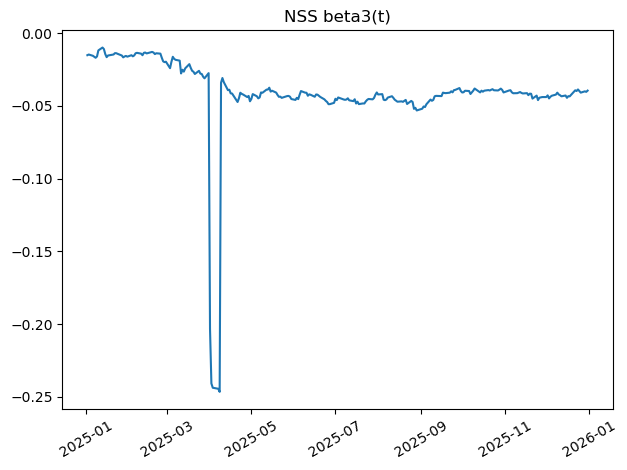

In [422]:
def plot_param(df, col, title=None):
    plt.figure()
    plt.plot(df["Date"], df[col])
    plt.title(title or col)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


plot_param(df_nss, "beta3", "NSS beta3(t)")

Compared with NS, NSS parameters are more flexible but also less stable and harder to interpret economically on a day-to-day basis.

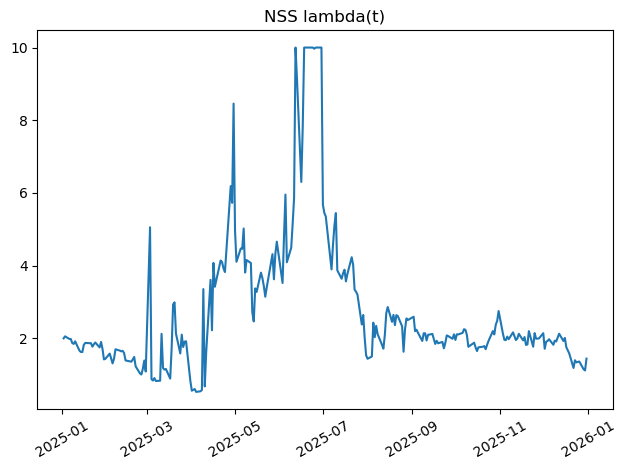

In [423]:
plot_param(df_nss, "lambda", "NSS lambda(t)")

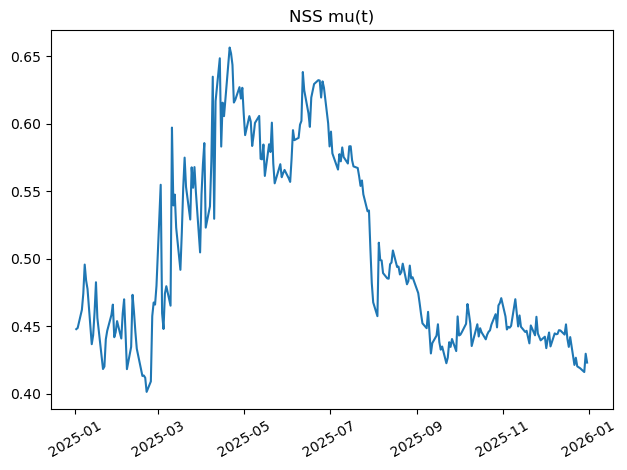

In [424]:
plot_param(df_nss, "mu", "NSS mu(t)")

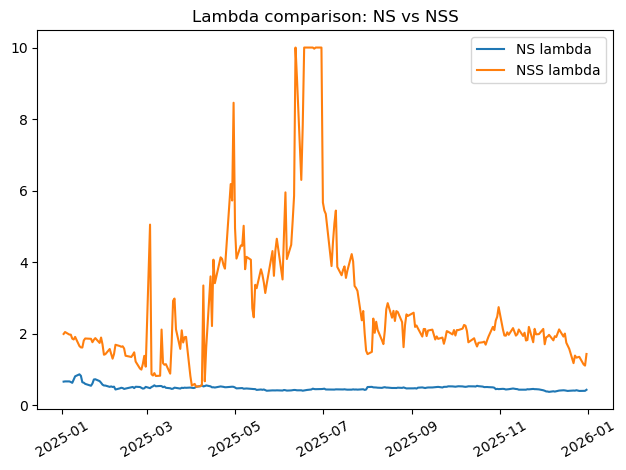

In [425]:
# compare NS and NSS's lambda
plt.figure()
plt.plot(df_ns["Date"], df_ns["lambda"], label="NS lambda")
plt.plot(df_nss["Date"], df_nss["lambda"], label="NSS lambda")
plt.title("Lambda comparison: NS vs NSS")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

In [426]:
df_compare[["rmse_ns_bp","rmse_nss_bp","rmse_gain_bp"]].describe()

,rmse_ns_bp,rmse_nss_bp,rmse_gain_bp
count,249.000000,249.000000,2.490000e+02
mean,4.430138,3.535399,8.947398e-01
std,1.277875,0.807949,7.281085e-01
min,2.542070,2.508730,-2.445524e-10
25%,3.514010,3.046234,2.457135e-01
50%,4.154592,3.244644,7.786863e-01
75%,5.136479,3.866705,1.380509e+00
max,10.532152,7.391384,3.475521e+00


For ```upper_lam = 5```, one has about 8% of hitting ratio, therefore we modify the upper bound to 15 or higher

In [427]:
# check whether we need to broaden bounds
upper_lam = 15.0
upper_mu  = 5.0

hit_lam = (df_nss["lambda"] >= upper_lam - 1e-6).mean()
hit_mu  = (df_nss["mu"]     >= upper_mu  - 1e-6).mean()

print("Lambda hits upper bound ratio:", hit_lam)
print("Mu hits upper bound ratio:", hit_mu)

# we prefer 10 over 5 for upper_lam, the latter has about 8% ratio

Lambda hits upper bound ratio: 0.0
Mu hits upper bound ratio: 0.0


# Out-Of-Sample Test ($t \to t+1$) 
## OOS Evaluation Design
For each trading day $t$, we use the parameters $\theta_t$ from day $t$ to predict the yield curve on day $t+1$ on the same available tenor grid:
$$\hat{y}_{t+1|t}(\tau_{i})=\hat{y}(\tau_i;\theta_t)$$
Then the OOS RMSE on day $t+1$ is computed as
$$\text{RMSE}^{OOS}(t+1)=\sqrt{\frac{1}{n}\sum_i (y_{t+1,i}-\hat{y}_{t+1,i})^2}$$
All OOS errors are reported in basis points (bp) in the comparison plots.

In [428]:
def oos_rmse_for_date(model, date, params, long_df):
    day = long_df[long_df["Date"]==date][["tenor_years","yield"]].copy().sort_values("tenor_years")
    tau = day["tenor_years"].to_numpy(float)
    y   = day["yield"].to_numpy(float)

    if model == "NS":
        yhat = ns_yield(tau, *params)  # params: [b0,b1,b2,lam]
    else:
        yhat = nss_yield(tau, *params) # params: [b0,b1,b2,b3,lam,mu]

    rmse = np.sqrt(np.mean((y - yhat)**2))
    return rmse

# use t's parameter to predict t + 1
dates = df_ns["Date"].tolist()  # or with  df_nss
oos_rows = []

for i in range(len(dates)-1):
    d_train = dates[i]
    d_test  = dates[i+1]

    p_ns  = df_ns.set_index("Date").loc[d_train, ["beta0","beta1","beta2","lambda"]].to_numpy(float)
    p_nss = df_nss.set_index("Date").loc[d_train, ["beta0","beta1","beta2","beta3","lambda","mu"]].to_numpy(float)

    rmse_oos_ns  = oos_rmse_for_date("NS",  d_test, p_ns,  long)
    rmse_oos_nss = oos_rmse_for_date("NSS", d_test, p_nss, long)

    oos_rows.append({
        "Date": d_test,
        "rmse_oos_ns_bp":  rmse_oos_ns  * 1e4,
        "rmse_oos_nss_bp": rmse_oos_nss * 1e4
    })

df_oos = pd.DataFrame(oos_rows).sort_values("Date").reset_index(drop=True)
df_oos["gain_oos_bp"] = df_oos["rmse_oos_ns_bp"] - df_oos["rmse_oos_nss_bp"]

df_oos.describe()

,Date,rmse_oos_ns_bp,rmse_oos_nss_bp,gain_oos_bp
count,248,248.000000,248.000000,248.000000
mean,2025-07-02 15:52:15.483870976,5.734513,5.031761,0.702752
min,2025-01-03 00:00:00,3.202391,2.934054,-0.137163
25%,2025-04-02 18:00:00,4.394741,3.752314,0.161461
50%,2025-07-02 12:00:00,5.342128,4.373687,0.563556
75%,2025-09-30 06:00:00,6.504864,5.686360,1.111968
max,2025-12-31 00:00:00,14.942455,15.008850,2.603884
std,NaN,1.839441,1.800424,0.633632


## OOS Result
NSS remains better on average in the $t \to t+1$ OOS test, but unlike the In-Sample case, it does not dominate on every date. This is an important result: the extra flexibility of NSS improves fit quality, yet can occasionally hurt short-horizon forecasting on specific days.

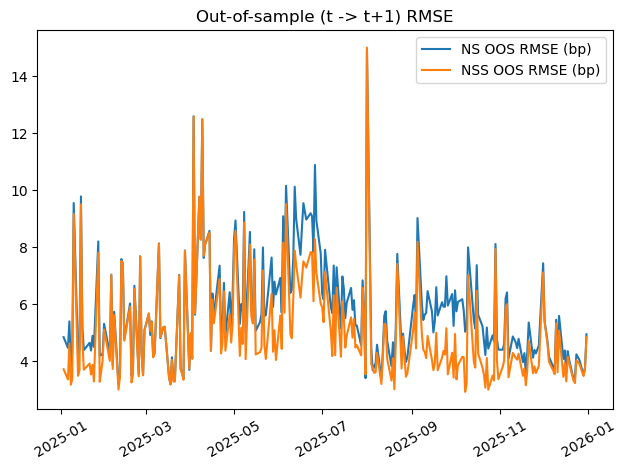

Share NSS improves OOS: 0.9354838709677419
       rmse_oos_ns_bp  rmse_oos_nss_bp  gain_oos_bp
count      248.000000       248.000000   248.000000
mean         5.734513         5.031761     0.702752
std          1.839441         1.800424     0.633632
min          3.202391         2.934054    -0.137163
25%          4.394741         3.752314     0.161461
50%          5.342128         4.373687     0.563556
75%          6.504864         5.686360     1.111968
max         14.942455        15.008850     2.603884


In [429]:
plt.figure()
plt.plot(df_oos["Date"], df_oos["rmse_oos_ns_bp"], label="NS OOS RMSE (bp)")
plt.plot(df_oos["Date"], df_oos["rmse_oos_nss_bp"], label="NSS OOS RMSE (bp)")
plt.title("Out-of-sample (t -> t+1) RMSE")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

print("Share NSS improves OOS:", (df_oos["gain_oos_bp"] > 0).mean())
print(df_oos[["rmse_oos_ns_bp","rmse_oos_nss_bp","gain_oos_bp"]].describe())

# Tenor-wise Diagnostics on Difficult Dates
## Identify Worst OOS Dates
When NSS underperforms NS in OOS, a plausible explanation is mild overfitting of day-$t$ local curve features. NSS can fit more detailed shape variations on the training day, but those variations may not persist to day $t+1$. In contrast, NS’s more parsimonious structure can be more stable under one-step-ahead parameter carry-forward forecasting.

In [430]:
df_oos.nsmallest(5, "gain_oos_bp")[["Date","rmse_oos_ns_bp","rmse_oos_nss_bp","gain_oos_bp"]]

,Date,rmse_oos_ns_bp,rmse_oos_nss_bp,gain_oos_bp
40,2025-03-04,4.929206,5.066368,-0.137163
143,2025-07-31,3.415741,3.550060,-0.134319
146,2025-08-05,3.686421,3.789013,-0.102592
67,2025-04-10,7.633048,7.701825,-0.068776
144,2025-08-01,14.942455,15.008850,-0.066395


In [431]:
tmp = df_oos.merge(
    df_params[["Date","beta1"]], on="Date", how="left"
)
tmp["slope_proxy_bp"] = (-tmp["beta1"]) * 1e4

tmp["bucket"] = pd.qcut(tmp["slope_proxy_bp"], 3, labels=["low","mid","high"])
tmp.groupby("bucket", observed=False)["gain_oos_bp"].agg(["mean","median","count"])

,mean,median,count
bucket,,,
low,0.267282,0.089031,83
mid,1.028378,1.003695,82
high,0.816518,0.638471,83


In [432]:
def diagnose_oos_by_tenor(test_date, long, df_ns, df_nss):
   
    test_date = pd.to_datetime(test_date)

    dates = sorted(pd.to_datetime(df_ns["Date"]).unique())
    if test_date not in dates:
        raise ValueError(f"{test_date.date()} is not in the df_ns dates (probably not trading day) ")

    idx = dates.index(test_date)
    if idx == 0:
        raise ValueError("No data for first trading day, diagnose for t->t+1 OOS cannot be done")

    train_date = dates[idx - 1]

    # take the market data from test date
    day = long[long["Date"] == test_date].copy()
    if day.empty:
        raise ValueError(f"long cannot find data for {test_date.date()} ")

    cols_needed = ["tenor_years", "yield"]
    if "tenor" in day.columns:
        cols_needed = ["tenor", "tenor_years", "yield"]

    day = day[cols_needed].sort_values("tenor_years").reset_index(drop=True)

    tau = day["tenor_years"].to_numpy(float)
    y_mkt = day["yield"].to_numpy(float)

    p_ns = (
        df_ns.loc[pd.to_datetime(df_ns["Date"]) == train_date, ["beta0","beta1","beta2","lambda"]]
        .iloc[0].to_numpy(float)
    )
    p_nss = (
        df_nss.loc[pd.to_datetime(df_nss["Date"]) == train_date, ["beta0","beta1","beta2","beta3","lambda","mu"]]
        .iloc[0].to_numpy(float)
    )
    
    y_ns = ns_yield(tau, *p_ns)
    y_nss = nss_yield(tau, *p_nss)

    out = day.copy()
    if "tenor" not in out.columns:
        out["tenor"] = out["tenor_years"].astype(str)

    out["yield_mkt"] = y_mkt
    out["yield_pred_ns"] = y_ns
    out["yield_pred_nss"] = y_nss

    # error (bp)
    out["err_ns_bp"] = (out["yield_mkt"] - out["yield_pred_ns"]) * 1e4
    out["err_nss_bp"] = (out["yield_mkt"] - out["yield_pred_nss"]) * 1e4

    # absolute error (bp)
    out["abs_err_ns_bp"] = out["err_ns_bp"].abs()
    out["abs_err_nss_bp"] = out["err_nss_bp"].abs()

    # >0 means NSS is better
    out["gain_by_tenor_bp"] = out["abs_err_ns_bp"] - out["abs_err_nss_bp"]

    # mark the better one
    out["winner"] = np.where(out["gain_by_tenor_bp"] > 0, "NSS", "NS")

    rmse_ns_bp = np.sqrt(np.mean(((y_mkt - y_ns) * 1e4)**2))
    rmse_nss_bp = np.sqrt(np.mean(((y_mkt - y_nss) * 1e4)**2))
    
    meta = {
        "train_date": train_date,
        "test_date": test_date,
        "rmse_ns_bp": rmse_ns_bp,
        "rmse_nss_bp": rmse_nss_bp,
        "gain_oos_bp": rmse_ns_bp - rmse_nss_bp
    }

    return out, meta

In [433]:
# plug in date like 2025-07-31
diag, meta = diagnose_oos_by_tenor("2025-07-31", long, df_ns, df_nss)

print(meta)
diag[[
    "tenor", "tenor_years",
    "yield_mkt", "yield_pred_ns", "yield_pred_nss",
    "err_ns_bp", "err_nss_bp",
    "abs_err_ns_bp", "abs_err_nss_bp",
    "gain_by_tenor_bp", "winner"
]]

{'train_date': Timestamp('2025-07-30 00:00:00'), 'test_date': Timestamp('2025-07-31 00:00:00'), 'rmse_ns_bp': 3.415741146246994, 'rmse_nss_bp': 3.550060312120062, 'gain_oos_bp': -0.1343191658730678}


,tenor,tenor_years,yield_mkt,yield_pred_ns,yield_pred_nss,err_ns_bp,err_nss_bp,abs_err_ns_bp,abs_err_nss_bp,gain_by_tenor_bp,winner
0,0.08333333333333333,0.083333,0.0449,0.044846,0.044618,0.538700,2.818665,0.538700,2.818665,-2.279965,NS
1,0.125,0.125000,0.0447,0.044625,0.044477,0.752496,2.227707,0.752496,2.227707,-1.475212,NS
2,0.16666666666666666,0.166667,0.0446,0.044410,0.044333,1.904921,2.666235,1.904921,2.666235,-0.761314,NS
3,0.25,0.250000,0.0441,0.043997,0.044039,1.030814,0.608017,1.030814,0.608017,0.422797,NSS
4,0.3333333333333333,0.333333,0.0440,0.043607,0.043740,3.926431,2.601389,3.926431,2.601389,1.325042,NSS
5,0.5,0.500000,0.0431,0.042893,0.043139,2.065118,-0.393714,2.065118,0.393714,1.671405,NSS
6,1.0,1.000000,0.0410,0.041211,0.041481,-2.114193,-4.805030,2.114193,4.805030,-2.690837,NS
7,2.0,2.000000,0.0394,0.039404,0.039356,-0.044520,0.443942,0.044520,0.443942,-0.399422,NS
8,3.0,3.000000,0.0389,0.038925,0.038700,-0.250464,1.999231,0.250464,1.999231,-1.748766,NS
9,5.0,5.000000,0.0396,0.039825,0.039685,-2.250777,-0.850654,2.250777,0.850654,1.400123,NSS


In [434]:
diag.sort_values("gain_by_tenor_bp").reset_index(drop=True)[[
    "tenor", "tenor_years",
    "err_ns_bp", "err_nss_bp",
    "abs_err_ns_bp", "abs_err_nss_bp",
    "gain_by_tenor_bp", "winner"
]]

,tenor,tenor_years,err_ns_bp,err_nss_bp,abs_err_ns_bp,abs_err_nss_bp,gain_by_tenor_bp,winner
0,1.0,1.000000,-2.114193,-4.805030,2.114193,4.805030,-2.690837,NS
1,0.08333333333333333,0.083333,0.538700,2.818665,0.538700,2.818665,-2.279965,NS
2,10.0,10.000000,-1.667049,-3.501441,1.667049,3.501441,-1.834391,NS
3,3.0,3.000000,-0.250464,1.999231,0.250464,1.999231,-1.748766,NS
4,0.125,0.125000,0.752496,2.227707,0.752496,2.227707,-1.475212,NS
5,0.16666666666666666,0.166667,1.904921,2.666235,1.904921,2.666235,-0.761314,NS
6,7.0,7.000000,-0.998674,-1.538667,0.998674,1.538667,-0.539993,NS
7,2.0,2.000000,-0.044520,0.443942,0.044520,0.443942,-0.399422,NS
8,20.0,20.000000,8.431506,8.108283,8.431506,8.108283,0.323222,NSS
9,0.25,0.250000,1.030814,0.608017,1.030814,0.608017,0.422797,NSS


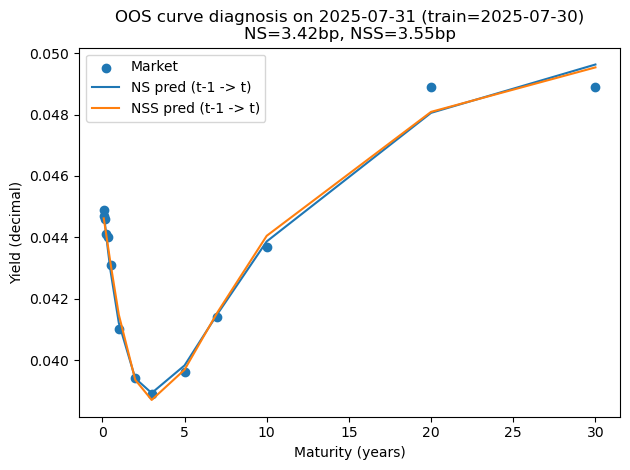

In [435]:
plt.figure()
plt.scatter(diag["tenor_years"], diag["yield_mkt"], label="Market")
plt.plot(diag["tenor_years"], diag["yield_pred_ns"], label="NS pred (t-1 -> t)")
plt.plot(diag["tenor_years"], diag["yield_pred_nss"], label="NSS pred (t-1 -> t)")
plt.title(
    f"OOS curve diagnosis on {pd.to_datetime(meta['test_date']).date()} "
    f"(train={pd.to_datetime(meta['train_date']).date()})\n"
    f"NS={meta['rmse_ns_bp']:.2f}bp, NSS={meta['rmse_nss_bp']:.2f}bp"
)
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (decimal)")
plt.legend()
plt.tight_layout()
plt.show()

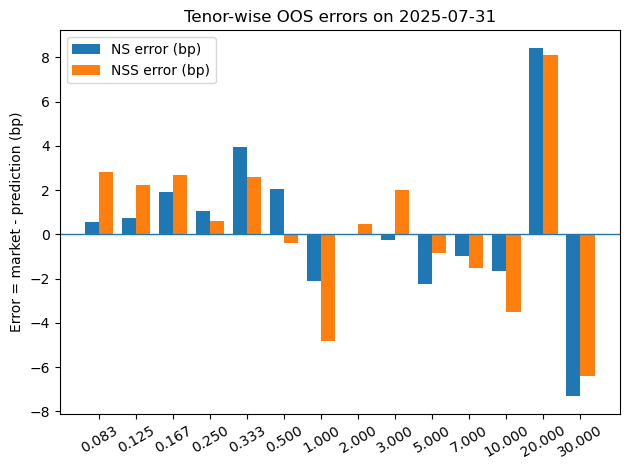

In [436]:
plt.figure()
x = np.arange(len(diag))
w = 0.38

tenor_vals = pd.to_numeric(diag["tenor_years"], errors="coerce")

labels = [f"{v:.3f}" if pd.notna(v) else "NA" for v in tenor_vals]


plt.bar(x - w/2, diag["err_ns_bp"], width=w, label="NS error (bp)")
plt.bar(x + w/2, diag["err_nss_bp"], width=w, label="NSS error (bp)")
plt.axhline(0, linewidth=1)
plt.xticks(x, labels, rotation=30)
plt.title(f"Tenor-wise OOS errors on {pd.to_datetime(meta['test_date']).date()}")
plt.ylabel("Error = market - prediction (bp)")
plt.legend()
plt.tight_layout()
plt.show()

In [437]:
# for the worst dates
worst_dates = df_oos.nsmallest(5, "gain_oos_bp")["Date"].tolist()

all_diag = []
for d in worst_dates:
    diag_i, meta_i = diagnose_oos_by_tenor(d, long, df_ns, df_nss)
    diag_i["Date"] = pd.to_datetime(d)
    all_diag.append(diag_i)

diag_worst = pd.concat(all_diag, ignore_index=True)

# gain < 0
diag_worst.groupby("tenor")["gain_by_tenor_bp"].agg(["mean","median","count"]).sort_values("mean")

,mean,median,count
tenor,,,
1.0,-1.868838,-1.589985,5
30.0,-0.556828,-1.116010,5
0.5,-0.354920,-0.594488,5
0.16666666666666666,-0.349231,-0.474694,5
20.0,-0.126830,-0.187302,5
0.3333333333333333,0.079035,-0.269257,5
0.25,0.148407,-0.043972,5
0.08333333333333333,0.229623,0.555889,5
10.0,0.298660,0.175916,5


In [438]:
diag2 = diag.copy()

diag2["bucket"] = pd.cut(
    diag2["tenor_years"],
    bins=[-np.inf, 1, 10, np.inf],
    labels=["short (<=1Y)", "belly (2Y-10Y)", "long (>10Y)"]
)

diag2.groupby("bucket")["gain_by_tenor_bp"].agg(["sum", "mean", "count"])

/var/folders/zt/lbh39vcn4ksbgkj7px6j4qxm0000gn/T/ipykernel_2686/3102410376.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diag2.groupby("bucket")["gain_by_tenor_bp"].agg(["sum", "mean", "count"])


,sum,mean,count
bucket,,,
short (<=1Y),-3.788084,-0.541155,7
belly (2Y-10Y),-3.122449,-0.624490,5
long (>10Y),1.263571,0.631785,2


# Limitations And Next Steps
- Uses par yields rather than zero-coupon yields (bootstrapping not performed)
- OOS forecast uses parameter carry-forward, no time-series model for parameters
- Sensitivity to initialization / local minima in nonlinear least squares

Future work: 
- Dynamic parameter modeling
- Regularization
- Zero-coupon curve construction